# Clipped-design objective sweep in the optimal voltage

The degree of freedom is the optimal (total) voltage $x = V_\mathrm{opt} = V - Z_0 I$, $I = W(V - x)$, $W = Z_0^{-1}$.
The objective is the radiated power of the structure obtained by inferring and clipping the density of $x$,
$$f(x) = \tfrac12 I_c^H R_0 I_c,\quad \sigma(x) = \frac{Z_s I(x)}{x},\quad \rho = \mathrm{clip}(\mathrm{Re}\,\sigma, 0, 1),\quad
I_c = (Z_s\mathbf 1 + \mathrm{diag}\,\rho\, Z_0)^{-1}\mathrm{diag}\,\rho\, V .$$
The voltage is kept at the Lagrangian distance $\varepsilon$ from the dual optimum,
$(x - x_\mathrm{opt})^H L^\star (x - x_\mathrm{opt}) = \varepsilon$, $L^\star = A(\lambda^\star)$,
and $\varepsilon$ is increased incrementally. Each step maximizes the second-order Taylor model of $f$ at the previous point,
made Hermitian by the Takagi bound (no real doubling), as a `DenseSharedProjQCQP` with a single general constraint.

The dual is the $V_\mathrm{sca}$ formulation of `quadraticInferenceParetoVoltage.ipynb` ($x_\mathrm{opt} = V + V_\mathrm{sca}^\star$, same $L^\star$),
refined by 20 GCD iterations, for the dipole or the 2:1 patch (`geometry`). Realizable binary designs lie on the clip kinks, so the binary pixels are fixed (active set)
and only the gray pixels are moved by the Taylor steps. The full structure is used for verification: it is realizable, so $f(x_\mathrm{full}) = P_\mathrm{full}$
and $P_\mathrm{full} = D - (x_\mathrm{full} - x_\mathrm{opt})^H L^\star (x_\mathrm{full} - x_\mathrm{opt})$.

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.linalg as sla
import time, warnings
from scipy.optimize import minimize
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters
import copy
import matplotlib.pyplot as plt
from dolphindes.cvxopt.gcd import GCDHyperparameters

## Parameters

In [2]:
geometry = "patch21ka1"   # "dipole" or "patch21ka1"
Ngcd = 20            # GCD iterations of the dual

epsMaxFactor = 1.2   # sweep up to epsMaxFactor * epsFull (Lagrangian distance of the full structure)
dEps0Factor = 1e-3   # first increment dEps0Factor * eps0 (eps0: distance of the start)
epsGrow = 1.5        # increment growth after an accepted step
epsShrink = 0.5      # increment reduction after a rejected step
maxSteps = 400       # maximum number of trial steps
stepTol = 0.05       # maximum relative step |x - x_k| / |x_k|
ratioTol = 0.1       # minimum ratio of the actual and the predicted (pessimistic) gain
resTol = 1e-4        # maximum relative residual of the eps constraint
INF_TOL = 1e-6       # dual tolerance of the step QCQP
projTol = 1e-2       # maximum relative change of eps by realizing the design after pixels are fixed

tolB = 1e-6          # densities within tolB of 0 or 1 are fixed (active set)
kappa = 5.0          # step length limit: kappa times the shortest step reaching eps
minGrayStep = 3      # step length constraint only with at least this many gray pixels
nRelease = 5         # maximum number of fixed pixels released per step

nStarts = 8          # initial densities of the start-point fit: 0.9, 0.5, 0.1 and random ones
startSeed = 1        # seed of the random initial densities
startMaxIter = 5000  # L-BFGS-B iterations of the start-point fit

In [3]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [4]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(f"Lmat_{geometry}.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(f"R0_{geometry}.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(f"X0_{geometry}.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(f"V_{geometry}.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  233
Objective for full plate: 4.114174e-02 W


## Objective and power conservation in $V_\mathrm{sca}$

With $I = -W V_\mathrm{sca}$, $W = Z_0^{-1}$, the radiated power is $-x^H A_0 x$ with $A_0 = -\tfrac12 W^H R_0 W$, and the power conservation
constraints take the shared projector form with $A_1 = 1 + Z_s^* W^H$, $A_2 = W$, $s_1 = -\tfrac12 V$ (derivation in `VscatBound.ipynb`).

In [5]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = np.zeros(Ndes, dtype=complex)
obj0 = 0.0

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

Vfull = -Z0 @ Ifull # scattered voltage for full plate
print(f"Objective for full plate in Vsca: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W)")

cond(Z0) = 1.174e+03
Objective for full plate in Vsca: 4.114174e-02 W (I basis 4.114174e-02 W)


In [6]:
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc

qList = [1, -1j]   # real and imaginary part (real and reactive power), p = q 1
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]   # P' = diag(p^*)

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def directRes(Vsca, p):
    # Re[I^H diag(p) (V + Vsca - Zs I)] evaluated directly
    I = VtoI(Vsca)
    return(np.real(np.sum(p*np.conj(I)*(Vinc + Vsca - Zs*I))))

print("power conservation residuals at full plate:",
      [f"{projRes(Vfull, Pp):.2e} (direct {directRes(Vfull, q*np.ones(Ndes)):.2e})" for Pp, q in zip(Plist, qList)])

# check: shared projector form equals the direct constraint for a random projector at a random point
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random p, random x: shared form {projRes(xRand, sp.diags(np.conj(pRand))):.6e}, direct {directRes(xRand, pRand):.6e}")

power conservation residuals at full plate: ['-1.39e-17 (direct -2.89e-17)', '4.44e-16 (direct -4.76e-16)']
random p, random x: shared form 2.174836e+00, direct 2.174836e+00


## Global bound

In [7]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

lags_init = np.array([1.0, 0.0])   # lambda = 1 on the real power constraint
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), full plate {Pfull:.6e} W")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist])

Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.847944e+01 W, time: 0.10s, Lagrange multipliers: [ 8.83797881e-01 -4.10993941e-05]
minimum eigenvalue of A: 6.851e-09
dual bound 1.847944e+01 W, P(x*) 1.847944e+01 W (I basis 1.847944e+01 W), full plate 4.114174e-02 W
constraint residuals at x*: ['-1.35e-07', '7.27e-04']


## Local projector constraints by GCD

In [8]:

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=opt_params)

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"bound: {QCQP.current_dual:.6e} -> {gQCQP.current_dual:.6e} W (full plate {Pfull:.6e} W), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             18.479439958269765.
min eigenvalue: 6.851365e-09
At GCD iteration #2, best dual bound found is             18.331563359435265.
min eigenvalue: 5.900530e-09


At GCD iteration #3, best dual bound found is             18.219582858778754.
min eigenvalue: 3.891571e-09
At GCD iteration #4, best dual bound found is             18.116345273290047.
min eigenvalue: 1.260088e-09


At GCD iteration #5, best dual bound found is             18.05814192950288.
min eigenvalue: 3.000881e-10


At GCD iteration #6, best dual bound found is             18.014874471916727.
min eigenvalue: 4.902920e-11


At GCD iteration #7, best dual bound found is             17.996930016252122.
min eigenvalue: 3.607517e-10


...

At GCD iteration #17, best dual bound found is             17.837742942723377.
min eigenvalue: 8.375653e-15


At GCD iteration #18, best dual bound found is             17.820182155128485.
min eigenvalue: 1.027706e-14


At GCD iteration #19, best dual bound found is             17.80211311949124.
min eigenvalue: 8.000442e-15


At GCD iteration #20, best dual bound found is             17.79105789262321.
min eigenvalue: 6.595286e-15


At GCD iteration #21, best dual bound found is             17.778704365753125.
bound: 1.847944e+01 -> 1.777870e+01 W (full plate 4.114174e-02 W), 42 projectors, 26.09s


In [9]:
# finetune the GCD multipliers with BFGS and check PSD-ness of A
t1 = time.time()
gcd_final_result = gQCQP.solve_current_dual_problem(method='bfgs', init_lags=gQCQP.current_lags, opt_params=None)
print(f"bound: {gcd_final_result[0]:.6e} W, time: {time.time()-t1:.2f}s")

print(f"min eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(gQCQP._get_total_A(gQCQP.current_lags)))):.3e}")
Vstar = gQCQP.current_xstar
print(f"GCD primal objective: {evalObj(Vstar):.6e} W, GCD dual bound: {gQCQP.current_dual:.6e} W")

bound: 1.777883e+01 W, time: 0.58s
min eigenvalue of A: 2.323e-14
GCD primal objective: 1.777829e+01 W, GCD dual bound: 1.777883e+01 W


## Clipped objective and its Taylor model

With the clip mask $m_i = [0 < \mathrm{Re}\,\sigma_i < 1]$, the derivatives with respect to the density are obtained by the adjoint
$p = M^{-H} R_0 I_c$, $M = Z_s\mathbf 1 + \mathrm{diag}\,\rho\, Z_0$, $W_\rho = M^{-1}\mathrm{diag}(V - Z_0 I_c)$:
$$g_\rho = \mathrm{Re}[\overline{(V - Z_0 I_c)} \circ p],\qquad
H_\rho = \mathrm{Re}[W_\rho^H R_0 W_\rho] - X - X^T,\quad X = \mathrm{Re}[\mathrm{diag}(\bar p) Z_0 W_\rho].$$
The density $\sigma$ is holomorphic in $x$ with Jacobian $G = -\mathrm{diag}(1/x)(Z_s W + \mathrm{diag}\,\sigma)$ and, contracted with
$w = m\circ g_\rho$, the second derivative $T = W^T\mathrm{diag}(c) + \mathrm{diag}(c) W + \mathrm{diag}(2 w Z_s I/x^3)$, $c = w Z_s / x^2$.
With $G_m = \mathrm{diag}(m) G$,
$$f(x+\delta) \approx f + \mathrm{Re}[g^H\delta] + \delta^H H \delta + \mathrm{Re}[\delta^T K \delta],\qquad
g = G_m^H g_\rho,\quad H = \tfrac14 G_m^H H_\rho G_m,\quad K = \tfrac14 G_m^T H_\rho G_m + \tfrac12 T .$$
The model is exact up to second order as long as the mask does not change.

In [10]:
Lstar = Msym(gQCQP._get_total_A(gQCQP.current_lags))   # quadratic part of the Lagrangian (shift invariant)
Pdual = gQCQP.current_dual
xopt = Vinc + gQCQP.current_xstar                          # optimal voltage V_opt = V + V_sca
Vzero = np.zeros(Ndes, dtype=complex)

def xtoI(x):
    return VtoI(x - Vinc)                                  # I = W (V - x)

def lagDist(x):
    e = x - xopt
    return np.real(e.conj() @ Lstar @ e)

def realizedI(rho):
    M = Zs*np.eye(Ndes) + rho[:, None]*Z0
    return np.linalg.solve(M, rho*Vinc), M

def clipMask(x):
    s = Zs*xtoI(x)/x
    return (s.real > 0) & (s.real < 1)

def clippedObj(x, derivs=True):
    # f(x) = P(I_c) of the clipped inferred density, and the Taylor data (g, H, K)
    I = xtoI(x)
    sig = Zs*I/x
    rho = np.clip(sig.real, 0, 1)
    Ic, M = realizedI(rho)
    f = evalObjI(Ic)
    if not derivs:
        return f, Ic, rho
    m = ((sig.real > 0) & (sig.real < 1)).astype(float)
    dc = Vinc - Z0 @ Ic
    Wr = np.linalg.solve(M, np.diag(dc))                  # dI_c / d rho
    p = np.linalg.solve(M.conj().T, R0 @ Ic)              # adjoint
    grho = np.real(dc.conj()*p)
    X = np.real(p.conj()[:, None]*(Z0 @ Wr))
    Hrho = np.real(Wr.conj().T @ R0 @ Wr) - X - X.T
    Gm = m[:, None]*(-(Zs*W + np.diag(sig))/x[:, None])
    w = m*grho
    c = w*Zs/x**2
    T = W.T*c[None, :] + c[:, None]*W + np.diag(2*w*Zs*I/x**3)
    g = Gm.conj().T @ grho
    H = Msym(0.25*Gm.conj().T @ Hrho @ Gm)
    K = 0.25*Gm.T @ Hrho @ Gm + 0.5*T
    return f, Ic, rho, g, H, 0.5*(K + K.T)

def model(f, g, H, K, d):
    return f + np.real(g.conj() @ d) + np.real(d.conj() @ H @ d) + np.real(d @ K @ d)

def takagiBound(K):
    # P = (K^H K)^{1/2}, so that |d^T K d| <= d^H P d
    _, s, Vh = np.linalg.svd(K)
    return Msym(Vh.conj().T @ (s[:, None]*Vh))

xfull = Vinc - Z0 @ Ifull
epsFull = lagDist(xfull)
print(f"dual bound {Pdual:.6e} W, full structure {Pfull:.6e} W, clipped full structure {clippedObj(xfull, False)[0]:.6e} W")
print(f"D - L*-distance of the full structure {Pdual - epsFull:.6e} W (epsFull = {epsFull:.4e})")
sig = Zs*xtoI(xopt)/xopt
print(f"x_opt: clipped objective {clippedObj(xopt, False)[0]:.4e} W, Re sigma in [{sig.real.min():.3f}, {sig.real.max():.3f}], "
      f"{clipMask(xopt).sum()} of {Ndes} in (0, 1)")

# finite-difference check: linear error O(t^2), quadratic model error O(t^3) while the mask is unchanged
rng = np.random.default_rng(0)
for name, xc in [('x_opt', xopt), ('perturbed', xopt*(1 + 0.05*(rng.standard_normal(Ndes) + 1j*rng.standard_normal(Ndes))))]:
    f0, _, _, g, H, K = clippedObj(xc)
    d = rng.standard_normal(Ndes) + 1j*rng.standard_normal(Ndes); d *= np.linalg.norm(xc)/np.linalg.norm(d)
    for t in [1e-4, 1e-5, 1e-6]:
        ft = clippedObj(xc + t*d, False)[0]
        print(f"{name:9s} t={t:.0e}: |f - lin| {abs(ft - f0 - np.real(g.conj() @ (t*d))):.2e}, "
              f"|f - quad| {abs(ft - model(f0, g, H, K, t*d)):.2e}, |df| {abs(ft - f0):.2e}")

dual bound 1.777883e+01 W, full structure 4.114174e-02 W, clipped full structure 4.114174e-02 W
D - L*-distance of the full structure 4.126291e-02 W (epsFull = 1.7738e+01)
x_opt: clipped objective 8.0082e-04 W, Re sigma in [-0.001, 0.005], 100 of 233 in (0, 1)
x_opt     t=1e-04: |f - lin| 5.73e-10, |f - quad| 1.14e-09, |df| 1.97e-07
x_opt     t=1e-05: |f - lin| 1.69e-11, |f - quad| 2.03e-13, |df| 1.97e-08
x_opt     t=1e-06: |f - lin| 1.71e-13, |f - quad| 2.09e-16, |df| 1.96e-09
perturbed t=1e-04: |f - lin| 1.70e-07, |f - quad| 9.13e-09, |df| 1.97e-06
perturbed t=1e-05: |f - lin| 1.61e-09, |f - quad| 8.80e-12, |df| 1.82e-07
perturbed t=1e-06: |f - lin| 1.61e-11, |f - quad| 8.77e-15, |df| 1.80e-08


## Starting point: minimal Lagrangian distance with meaningful densities

The dual optimum $x_\mathrm{opt}$ infers densities close to zero, so the sweep starts from the realized voltage of the density
$\rho \in [0,1]^N$ closest to the dual optimum in the Lagrangian norm,
$$\min_{\rho\in[0,1]^N} \left(x(\rho) - x_\mathrm{opt}\right)^H L^\star \left(x(\rho) - x_\mathrm{opt}\right),\qquad
x(\rho) = V - Z_0 I_c(\rho),$$
solved by L-BFGS-B with the adjoint gradient $-2\,\mathrm{Re}[\overline{p}\circ(V - Z_0 I_c)]$, $p = M^{-H} Z_0^H L^\star (x - x_\mathrm{opt})$,
from several initial densities. The inferred density of $x(\rho)$ is $\rho$ itself, so its clipped objective is the realized
power of $\rho$. For a gray $\rho$ (material $Z_s/\rho$) the dual constraints do not hold, so $f \ne D - \varepsilon$ in general.

In [11]:
def distRho(rho):
    Ic, M = realizedI(rho)
    x = Vinc - Z0 @ Ic
    e = x - xopt
    p = np.linalg.solve(M.conj().T, Z0.conj().T @ (Lstar @ e))
    return np.real(e.conj() @ Lstar @ e), -2*np.real(p.conj()*(Vinc - Z0 @ Ic))

srng = np.random.default_rng(startSeed)
rhoInits = [0.9*np.ones(Ndes), 0.5*np.ones(Ndes), 0.1*np.ones(Ndes)] + [srng.uniform(0, 1, Ndes) for _ in range(nStarts - 3)]
fits = []
for k, r in enumerate(rhoInits):
    res = minimize(distRho, r, jac=True, method='L-BFGS-B', bounds=[(0, 1)]*Ndes,
                   options=dict(maxiter=startMaxIter, ftol=1e-15, gtol=1e-14))
    Ic, _ = realizedI(res.x)
    fits.append((res.fun, res.x))
    print(f"init {k}: L*-distance {res.fun:.6e} (full structure {epsFull:.6e}), P {evalObjI(Ic):.6e} W, fill {res.x.mean():.3f}, "
          f"gray {np.mean((res.x > 1e-3) & (res.x < 1 - 1e-3)):.2f}, {res.nit} it")
eps0, rho0 = min(fits, key=lambda t: t[0])
x0 = Vinc - Z0 @ realizedI(rho0)[0]
print(f"start: eps0 {eps0:.6e}, clipped objective {clippedObj(x0, False)[0]:.6e} W, "
      f"max |sigma - rho0| {np.abs(Zs*xtoI(x0)/x0 - rho0).max():.1e}, {clipMask(x0).sum()} of {Ndes} strictly inside (0, 1)")

init 0: L*-distance 1.296950e+01 (full structure 1.773756e+01), P 1.554460e+00 W, fill 0.557, gray 0.90, 1364 it


init 1: L*-distance 1.609510e+01 (full structure 1.773756e+01), P 1.267844e-01 W, fill 0.044, gray 0.37, 5000 it


init 2: L*-distance 9.832699e+00 (full structure 1.773756e+01), P 6.804860e+00 W, fill 0.348, gray 0.63, 875 it


init 3: L*-distance 1.765430e+01 (full structure 1.773756e+01), P 4.311767e-02 W, fill 0.492, gray 0.92, 2748 it


init 4: L*-distance 1.767014e+01 (full structure 1.773756e+01), P 5.222732e-02 W, fill 0.456, gray 0.87, 5000 it


init 5: L*-distance 1.639462e+01 (full structure 1.773756e+01), P 7.656042e-02 W, fill 0.045, gray 0.08, 5000 it


init 6: L*-distance 1.766899e+01 (full structure 1.773756e+01), P 4.266142e-02 W, fill 0.505, gray 0.93, 5000 it


init 7: L*-distance 1.766351e+01 (full structure 1.773756e+01), P 4.405240e-02 W, fill 0.482, gray 0.85, 5000 it
start: eps0 9.832699e+00, clipped objective 6.804860e+00 W, max |sigma - rho0| 1.8e-09, 202 of 233 strictly inside (0, 1)


## Active set: fixed binary pixels

A realizable binary design sits on the clip kinks, $\sigma_i = 0$ (empty) or $\sigma_i = 1$ (full), where the clipped objective has
only one-sided derivatives. These pixels are therefore fixed by linear equalities on the voltage,
$$i_i = [W(V - x)]_i = 0,\ i\in\mathcal E, \qquad Z_s i_i = x_i,\ i\in\mathcal F,$$
i.e. $C x = d$, and the step is taken in the null space, $x = x_k + N z$, $CN = 0$. Only the gray pixels $\mathcal A$ move,
their mask is $m_i = [i\in\mathcal A]$, and the Taylor model $g_z = N^H g$, $H_z = N^H (H - P) N$ is valid until a gray density
reaches a bound.

On the level set of the offset ellipsoid, the maximizer of the model may lie on its far side, so the step is also limited by
$z^H N^H L^\star N z = \kappa^2 r_\mathrm{min}^2$, with $r_\mathrm{min} = |\varepsilon - \varepsilon_k| / (2\|N^H L^\star e\|_{(N^H L^\star N)^{-1}})$
the shortest step reaching $\varepsilon$. Both constraints are complex Hermitian (strong duality for two constraints), and the
step is a `DenseSharedProjQCQP` with two general constraints (one when fewer than `minGrayStep` gray pixels remain).

After a step, gray pixels that left $(0, 1)$ join $\mathcal E$ or $\mathcal F$ and the voltage is replaced by the realized voltage
$V - Z_0 I_c(\rho)$ of its clipped density. This keeps $f$, satisfies the new constraints exactly and makes all gray densities real,
which a minimal $L^\star$-norm projection does not: $\sigma = Z_s I/x$ is very sensitive to $x$. Only $\varepsilon$ changes, and the
acceptance test is applied to the realized point. Fixed pixels whose
one-sided density derivative favours leaving the bound are released (at most `nRelease` per step). At the end, the remaining
gray pixels are snapped greedily to the better bound.

In [12]:
inf_opt = OptimizationHyperparameters(opttol=INF_TOL, gradConverge=True, min_inner_iter=5, max_restart=10,
                                      penalty_ratio=1e-2, penalty_reduction=0.1, break_iter_period=5, verbose=0)

def clippedObjA(x, E, F, derivs=True):
    # clipped objective with the pixels E and F fixed at rho = 0 and 1; also returns the density gradient
    I = xtoI(x)
    sig = Zs*I/x
    rho = np.clip(sig.real, 0, 1); rho[E] = 0; rho[F] = 1
    Ic, M = realizedI(rho)
    f = evalObjI(Ic)
    if not derivs:
        return f, Ic, rho
    m = np.ones(Ndes); m[E] = 0; m[F] = 0
    dc = Vinc - Z0 @ Ic
    Wr = np.linalg.solve(M, np.diag(dc))
    p = np.linalg.solve(M.conj().T, R0 @ Ic)
    grho = np.real(dc.conj()*p)
    X = np.real(p.conj()[:, None]*(Z0 @ Wr))
    Hrho = np.real(Wr.conj().T @ R0 @ Wr) - X - X.T
    Gm = m[:, None]*(-(Zs*W + np.diag(sig))/x[:, None])
    w = m*grho
    c = w*Zs/x**2
    T = W.T*c[None, :] + c[:, None]*W + np.diag(2*w*Zs*I/x**3)
    K = 0.25*Gm.T @ Hrho @ Gm + 0.5*T
    return f, Ic, rho, Gm.conj().T @ grho, Msym(0.25*Gm.conj().T @ Hrho @ Gm), 0.5*(K + K.T), grho

def fixedConstraints(E, F):
    # C x = d:  I_i = 0 on E,  Zs I_i = x_i on F,  with I = W (V - x)
    bW = W @ Vinc
    C = np.vstack([W[E], Zs*W[F] + np.eye(Ndes)[F]])
    return C, np.concatenate([bW[E], Zs*bW[F]])

def realizeFixed(x, E, F):
    # voltage of the realized clipped density: keeps f, satisfies the fixed-pixel constraints exactly, makes sigma real
    return Vinc - Z0 @ clippedObjA(x, E, F, False)[1]

def activeStep(xk, eps, E, F, data, lags0=None):
    f, _, _, g, H, K, _ = data
    Nb = sla.null_space(fixedConstraints(E, F)[0]) if len(E) + len(F) else np.eye(Ndes, dtype=complex)
    na = Nb.shape[1]
    Hm = Msym(Nb.conj().T @ (H - takagiBound(K)) @ Nb)
    gz = Nb.conj().T @ g
    Lz = Msym(Nb.conj().T @ Lstar @ Nb)
    epsk = lagDist(xk)
    a = Nb.conj().T @ (Lstar @ (xk - xopt))
    rmin = abs(eps - epsk)/(2*np.sqrt(np.real(a.conj() @ np.linalg.solve(Lz, a))))   # shortest step reaching eps
    r2 = (kappa*rmin)**2
    z0 = np.zeros(na, dtype=complex)
    sc = 1/abs(f)                                      # scale the objective to O(1)
    # -z^H (Lz/eps) z - 2Re[z^H a]/eps + 1 - epsk/eps = 0   and   -z^H (Lz/r2) z + 1 = 0
    twoC = na >= minGrayStep
    Bj, sj, cj = [Lz/eps], [-a/eps], [1 - epsk/eps]
    if twoC:
        Bj, sj, cj = Bj + [Lz/r2], sj + [z0], cj + [1.0]
    Q = DenseSharedProjQCQP(-sc*Hm, 0.5*sc*gz, sc*f, np.eye(na, dtype=complex), z0,
                            [], Pstruct=sp.eye(na),   # no projector constraints
                            B_j=Bj, s_2j=sj, c_2j=cj, verbose=0)
    if lags0 is None or len(lags0) != len(Bj):   # make the Lagrangian matrix positive definite
        lmin = sla.eigh(-sc*Hm, sum(Bj), eigvals_only=True, subset_by_index=[0, 0])[0]
        lags0 = np.ones(len(Bj))*(max(-lmin, 0)*1.5 + 1.0)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Q.solve_current_dual_problem(method='newton', init_lags=lags0, opt_params=inf_opt)
    except (ValueError, np.linalg.LinAlgError):
        return None
    z = Q.current_xstar
    res = abs(lagDist(xk + Nb @ z) - eps)/eps
    if twoC:
        res = max(res, abs(np.real(z.conj() @ Lz @ z) - r2)/r2)
    return dict(x=xk + Nb @ z, res=res, lags=Q.current_lags, na=na, dual=Q.current_dual/sc,
                pess=f + np.real(gz.conj() @ z) + np.real(z.conj() @ Hm @ z))

def releasePixels(E, F, grho):
    # free fixed pixels whose one-sided density derivative favours leaving the bound
    cand = [(grho[i], i) for i in E if grho[i] > 0] + [(-grho[i], i) for i in F if grho[i] < 0]
    free = [i for _, i in sorted(cand, reverse=True)[:nRelease]]
    return np.setdiff1d(E, free).astype(int), np.setdiff1d(F, free).astype(int), len(free)

E0 = np.flatnonzero(rho0 <= tolB)
F0 = np.flatnonzero(rho0 >= 1 - tolB)
x0A = realizeFixed(x0, E0, F0)   # densities within tolB of a bound are set to it
print(f"start: {len(E0)} empty, {len(F0)} full, {Ndes - len(E0) - len(F0)} gray pixels; "
      f"rounding changes eps by {abs(lagDist(x0A) - eps0)/eps0:.1e}")

# check of the first step: constraint residuals, zero duality gap, Takagi bracket
dataA = clippedObjA(x0A, E0, F0)
st = activeStep(x0A, lagDist(x0A)*(1 + dEps0Factor), E0, F0, dataA)
print(f"first step: residual {st['res']:.1e}, dual {st['dual']:.8e}, model at x* {st['pess']:.8e}, "
      f"actual {clippedObjA(st['x'], E0, F0, False)[0]:.8e} W (start {dataA[0]:.8e} W)")

start: 65 empty, 1 full, 167 gray pixels; rounding changes eps by 2.3e-10
first step: residual 9.1e-08, dual 6.82835232e+00, model at x* 6.82835231e+00, actual 6.82909054e+00 W (start 6.80486023e+00 W)


## Incremental $\varepsilon$-sweep

A step is accepted if both constraints are met, the realized point stays close to the $\varepsilon$ level set, the step is small and the
actual gain is at least `ratioTol` of the predicted (pessimistic) gain; otherwise the increment is reduced.

In [13]:
epsMax = epsMaxFactor*epsFull
E, F = E0.copy(), F0.copy()
xk = x0A; epsk = lagDist(xk)
data = clippedObjA(xk, E, F); fk = data[0]
E, F, _ = releasePixels(E, F, data[6]); data = clippedObjA(xk, E, F)
lags, dEps = None, dEps0Factor*epsk
pts = [(epsk, fk, Ndes - len(E) - len(F))]
nAcc, nRej, t0 = 0, 0, time.time()
for it in range(maxSteps):
    if epsk >= epsMax or dEps < 1e-12*epsMax or len(E) + len(F) == Ndes:
        break
    epsTry = min(epsk + dEps, epsMax)
    st = activeStep(xk, epsTry, E, F, data, lags)
    if st is None:
        dEps *= epsShrink; lags = None; nRej += 1
        continue
    x = st['x']
    sig = Zs*xtoI(x)/x
    gray = np.ones(Ndes, bool); gray[E] = False; gray[F] = False
    newE, newF = np.flatnonzero(gray & (sig.real <= 0)), np.flatnonzero(gray & (sig.real >= 1))
    E2, F2 = np.union1d(E, newE).astype(int), np.union1d(F, newF).astype(int)
    if len(newE) + len(newF):
        x = realizeFixed(x, E2, F2)
    f = clippedObjA(x, E2, F2, False)[0]
    ratio = (f - fk)/(st['pess'] - fk)
    relStep = np.linalg.norm(x - xk)/np.linalg.norm(xk)
    epsRes = abs(lagDist(x) - epsTry)/epsTry
    ok = st['res'] < resTol and epsRes < projTol and relStep < stepTol and ratio > ratioTol
    if ok:
        E, F, xk, epsk, fk, lags = E2, F2, x, lagDist(x), f, st['lags']
        data = clippedObjA(xk, E, F)
        E, F, nFree = releasePixels(E, F, data[6])
        if nFree:
            data = clippedObjA(xk, E, F); lags = None
        dEps *= epsGrow; nAcc += 1
        pts.append((epsk, fk, Ndes - len(E) - len(F)))
        print(f"  [{it:3d}] eps {epsk:.6e}: f {f:.6e} W, predicted {st['pess']:.6e}, ratio {ratio:5.2f}, |dx|/|x| {relStep:.1e}, "
              f"gray {pts[-1][2]:3d} (+{len(newE)} empty, +{len(newF)} full, {nFree} released)")
    else:
        dEps *= epsShrink; lags = None; nRej += 1
print(f"{nAcc} accepted, {nRej} rejected, {time.time() - t0:.1f}s; eps {epsk:.4e} of {epsMax:.4e}, {pts[-1][2]} gray pixels left")

# snap the remaining gray pixels greedily to the better bound
sig = Zs*xtoI(xk)/xk
for i in sorted(np.setdiff1d(np.arange(Ndes), np.union1d(E, F)), key=lambda i: -abs(sig[i].real - 0.5)):
    trials = [(np.union1d(E, [i]).astype(int), F), (E, np.union1d(F, [i]).astype(int))]
    vals = [clippedObjA(xk, *t, False)[0] for t in trials]
    E, F = trials[int(np.argmax(vals))]
xb = realizeFixed(xk, E, F)
fb, Ib, rhob = clippedObjA(xb, E, F, False)
epsb = lagDist(xb)
pts.append((epsb, fb, 0))
pts = np.array(pts)
print(f"binary design: {len(F)} full, {len(E)} empty, P {fb:.6e} W, eps {epsb:.6e}, D - eps {Pdual - epsb:.6e} W")
print(f"start {pts[0, 1]:.6e} W, best gray {pts[:-1, 1].max():.6e} W, full structure {Pfull:.6e} W (eps {epsFull:.6e}), dual bound {Pdual:.6e} W")

  [  0] eps 9.833223e+00: f 6.829091e+00 W, predicted 6.828352e+00, ratio  1.03, |dx|/|x| 4.8e-03, gray 156 (+1 empty, +10 full, 0 released)
  [  1] eps 9.847481e+00: f 6.860949e+00 W, predicted 6.861749e+00, ratio  0.98, |dx|/|x| 1.2e-02, gray 153 (+2 empty, +1 full, 0 released)
  [  2] eps 9.848211e+00: f 6.911293e+00 W, predicted 6.907751e+00, ratio  1.08, |dx|/|x| 6.3e-03, gray 148 (+0 empty, +5 full, 0 released)
  [  3] eps 9.850247e+00: f 6.986690e+00 W, predicted 6.979594e+00, ratio  1.10, |dx|/|x| 9.4e-03, gray 138 (+0 empty, +10 full, 0 released)
  [  4] eps 9.855940e+00: f 7.103853e+00 W, predicted 7.085045e+00, ratio  1.19, |dx|/|x| 1.4e-02, gray 127 (+0 empty, +11 full, 0 released)


  [  5] eps 9.871374e+00: f 7.289219e+00 W, predicted 7.235431e+00, ratio  1.41, |dx|/|x| 2.2e-02, gray 103 (+0 empty, +24 full, 0 released)
  [  8] eps 9.878707e+00: f 7.362020e+00 W, predicted 7.474620e+00, ratio  0.39, |dx|/|x| 8.4e-03, gray  86 (+1 empty, +16 full, 0 released)
  [  9] eps 9.895636e+00: f 7.479565e+00 W, predicted 7.450063e+00, ratio  1.34, |dx|/|x| 1.5e-02, gray  70 (+0 empty, +16 full, 0 released)
  [ 10] eps 9.928071e+00: f 7.656600e+00 W, predicted 7.554272e+00, ratio  2.37, |dx|/|x| 2.2e-02, gray  36 (+0 empty, +34 full, 0 released)


  [ 13] eps 9.946622e+00: f 7.741439e+00 W, predicted 7.698325e+00, ratio  2.03, |dx|/|x| 1.1e-02, gray  16 (+0 empty, +20 full, 0 released)
  [ 16] eps 9.957084e+00: f 7.785712e+00 W, predicted 7.760716e+00, ratio  2.30, |dx|/|x| 5.5e-03, gray   7 (+0 empty, +9 full, 0 released)
  [ 19] eps 9.961349e+00: f 7.803196e+00 W, predicted 7.789725e+00, ratio  4.36, |dx|/|x| 2.2e-03, gray   5 (+0 empty, +2 full, 0 released)


  [ 22] eps 9.963098e+00: f 7.810268e+00 W, predicted 7.805120e+00, ratio  3.68, |dx|/|x| 8.8e-04, gray   4 (+0 empty, +1 full, 0 released)
  [ 25] eps 9.963841e+00: f 7.813257e+00 W, predicted 7.811236e+00, ratio  3.09, |dx|/|x| 3.7e-04, gray   3 (+0 empty, +1 full, 0 released)
  [ 28] eps 9.964161e+00: f 7.814543e+00 W, predicted 7.813882e+00, ratio  2.06, |dx|/|x| 1.6e-04, gray   1 (+0 empty, +2 full, 0 released)


  [ 37] eps 9.964162e+00: f 7.814543e+00 W, predicted 7.814543e+00, ratio  1.60, |dx|/|x| 1.2e-07, gray   0 (+0 empty, +1 full, 0 released)
16 accepted, 22 rejected, 1.1s; eps 9.9642e+00 of 2.1285e+01, 0 gray pixels left
binary design: 164 full, 69 empty, P 7.814543e+00 W, eps 9.964162e+00, D - eps 7.814664e+00 W
start 6.804860e+00 W, best gray 7.814543e+00 W, full structure 4.114174e-02 W (eps 1.773756e+01), dual bound 1.777883e+01 W


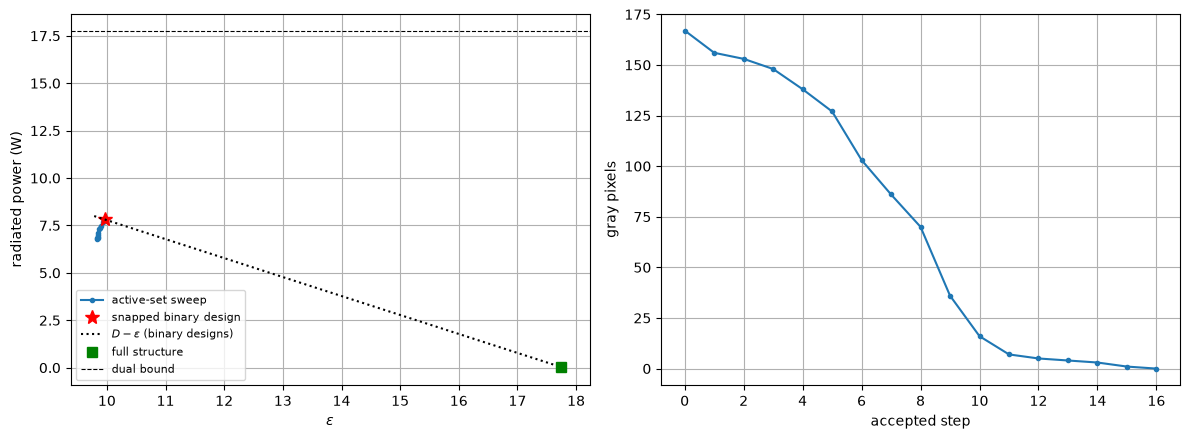

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axs[0]
ax.plot(pts[:-1, 0], pts[:-1, 1], 'o-', ms=3, label='active-set sweep')
ax.plot(pts[-1, 0], pts[-1, 1], 'r*', ms=10, label='snapped binary design')
eg = np.linspace(min(pts[:, 0].min(), epsFull)*0.995, max(pts[:, 0].max(), epsFull)*1.005, 100)
ax.plot(eg, Pdual - eg, 'k:', label=r'$D - \varepsilon$ (binary designs)')
ax.plot(epsFull, Pfull, 'gs', ms=7, label='full structure')
ax.axhline(Pdual, ls='--', c='k', lw=0.8, label='dual bound')
ax.set_xlabel(r'$\varepsilon$'); ax.set_ylabel('radiated power (W)'); ax.grid(True); ax.legend(fontsize=8)
ax = axs[1]
ax.plot(np.arange(len(pts) - 1), pts[:-1, 2], 'o-', ms=3)
ax.set_xlabel('accepted step'); ax.set_ylabel('gray pixels'); ax.grid(True)
plt.tight_layout(); plt.show()

np.savetxt(f'clipped_objective_sweep_{geometry}.txt', pts, delimiter=',', header='eps,f_clip,n_gray')